In [1]:

# Import libraries
import pandas as pd
import numpy as np

# Load dataset
file_path = "drug_consumption.data"
df = pd.read_csv(file_path, header=None)

print("Shape:", df.shape)
df.head()


Shape: (1885, 32)


,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,1,0.49788,0.48246,-0.05921,0.96082,0.12600,0.31287,-0.57545,-0.58331,-0.91699,...,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL2,CL0,CL0
1,2,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.67825,1.93886,1.43533,0.76096,...,CL4,CL0,CL2,CL0,CL2,CL3,CL0,CL4,CL0,CL0
2,3,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,...,CL0,CL0,CL0,CL0,CL0,CL0,CL1,CL0,CL0,CL0
3,4,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,...,CL0,CL0,CL2,CL0,CL0,CL0,CL0,CL2,CL0,CL0
4,5,0.49788,0.48246,1.98437,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,...,CL1,CL0,CL0,CL1,CL0,CL0,CL2,CL2,CL0,CL0


In [2]:

# Add proper column names (UCI Drug Consumption dataset standard)
col_names = [
    "ID","Age","Gender","Education","Country","Ethnicity",
    "Nscore","Escore","Oscore","Ascore","Cscore","Impulsive","SS",
    "Alcohol","Amphet","Amyl","Benzos","Caff","Cannabis","Choc","Coke","Crack",
    "Ecstasy","Heroin","Ketamine","Legalh","LSD","Meth","Mushrooms","Nicotine","Semer","VSA"
]
df.columns = col_names

print("Columns assigned:", len(df.columns))
df.head()


Columns assigned: 32


,ID,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,...,Ecstasy,Heroin,Ketamine,Legalh,LSD,Meth,Mushrooms,Nicotine,Semer,VSA
0,1,0.49788,0.48246,-0.05921,0.96082,0.12600,0.31287,-0.57545,-0.58331,-0.91699,...,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL2,CL0,CL0
1,2,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.67825,1.93886,1.43533,0.76096,...,CL4,CL0,CL2,CL0,CL2,CL3,CL0,CL4,CL0,CL0
2,3,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,...,CL0,CL0,CL0,CL0,CL0,CL0,CL1,CL0,CL0,CL0
3,4,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,...,CL0,CL0,CL2,CL0,CL0,CL0,CL0,CL2,CL0,CL0
4,5,0.49788,0.48246,1.98437,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,...,CL1,CL0,CL0,CL1,CL0,CL0,CL2,CL2,CL0,CL0


In [3]:

# Basic cleaning checks (missing + duplicates)
print("Missing values per column (should be 0):")
print(df.isnull().sum().sum())

dup_count = df.duplicated().sum()
print("Duplicate rows:", dup_count)

# If duplicates exist, remove them (safe step)
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after duplicate removal:", df.shape)


Missing values per column (should be 0):
0
Duplicate rows: 0
Shape after duplicate removal: (1885, 32)


In [4]:

# Convert drug usage labels (CL0..CL6) to ordered numeric classes 0..6
drug_cols = col_names[13:]  # all drug columns

class_map = {f"CL{i}": i for i in range(7)}

for c in drug_cols:
    df[c] = df[c].map(class_map).astype(int)

print("Drug columns converted to numeric classes (0..6).")
df[drug_cols].head()


Drug columns converted to numeric classes (0..6).


,Alcohol,Amphet,Amyl,Benzos,Caff,Cannabis,Choc,Coke,Crack,Ecstasy,Heroin,Ketamine,Legalh,LSD,Meth,Mushrooms,Nicotine,Semer,VSA
0,5,2,0,2,6,0,5,0,0,0,0,0,0,0,0,0,2,0,0
1,5,2,2,0,6,4,6,3,0,4,0,2,0,2,3,0,4,0,0
2,6,0,0,0,6,3,4,0,0,0,0,0,0,0,0,1,0,0,0
3,4,0,0,3,5,2,4,2,0,0,0,2,0,0,0,0,2,0,0
4,4,1,1,0,6,3,6,0,0,1,0,0,1,0,0,2,2,0,0


In [5]:
# Cell 6
# Create binary drug-use flags (simple version)
# Here: 0 = Never used (CL0), 1 = Used at least once (CL1..CL6)
for c in drug_cols:
    df[c + "_binary"] = (df[c] >= 1).astype(int)

print("Binary drug-use columns created.")
df[[drug_cols[0], drug_cols[0] + "_binary"]].head()


Binary drug-use columns created.


,Alcohol,Alcohol_binary
0,5,1
1,5,1
2,6,1
3,4,1
4,4,1


In [6]:
# Cell 7
# Final cleaning step: remove duplicates and null values

print("Before cleaning:")
print("Shape:", df.shape)
print("Total Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

# Remove null values (extra safety, dataset already clean)
df = df.dropna()

# Reset index
df = df.reset_index(drop=True)

print("\nAfter cleaning:")
print("Shape:", df.shape)
print("Total Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())


Before cleaning:
Shape: (1885, 51)
Total Missing Values: 0
Duplicate Rows: 0

After cleaning:
Shape: (1885, 51)
Total Missing Values: 0
Duplicate Rows: 0


In [7]:
# -----------------------------
# Dataset structure information
# -----------------------------
print("Dataset shape (rows, columns):", df.shape)

print("\nColumn data types:")
print(df.dtypes)

print("\nFirst 5 rows:")
df.head()

Dataset shape (rows, columns): (1885, 51)

Column data types:
ID                    int64
Age                 float64
Gender              float64
Education           float64
Country             float64
Ethnicity           float64
Nscore              float64
Escore              float64
Oscore              float64
Ascore              float64
Cscore              float64
Impulsive           float64
SS                  float64
Alcohol               int64
Amphet                int64
Amyl                  int64
Benzos                int64
Caff                  int64
Cannabis              int64
Choc                  int64
Coke                  int64
Crack                 int64
Ecstasy               int64
Heroin                int64
Ketamine              int64
Legalh                int64
LSD                   int64
Meth                  int64
Mushrooms             int64
Nicotine              int64
Semer                 int64
VSA                   int64
Alcohol_binary        int64
Amphet_binary 

,ID,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,...,Ecstasy_binary,Heroin_binary,Ketamine_binary,Legalh_binary,LSD_binary,Meth_binary,Mushrooms_binary,Nicotine_binary,Semer_binary,VSA_binary
0,1,0.49788,0.48246,-0.05921,0.96082,0.12600,0.31287,-0.57545,-0.58331,-0.91699,...,0,0,0,0,0,0,0,1,0,0
1,2,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.67825,1.93886,1.43533,0.76096,...,1,0,1,0,1,1,0,1,0,0
2,3,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,...,0,0,0,0,0,0,1,0,0,0
3,4,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,...,0,0,1,0,0,0,0,1,0,0
4,5,0.49788,0.48246,1.98437,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,...,1,0,0,1,0,0,1,1,0,0


In [8]:
# -----------------------------
# Descriptive statistics
# -----------------------------
print("Statistical Summary:")
df.describe().T

Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
ID,1885.0,945.294960,545.167641,1.00000,474.00000,946.00000,1417.00000,1888.00000
Age,1885.0,0.034610,0.878360,-0.95197,-0.95197,-0.07854,0.49788,2.59171
Gender,1885.0,-0.000256,0.482588,-0.48246,-0.48246,-0.48246,0.48246,0.48246
Education,1885.0,-0.003806,0.950078,-2.43591,-0.61113,-0.05921,0.45468,1.98437
Country,1885.0,0.355542,0.700335,-0.57009,-0.57009,0.96082,0.96082,0.96082
Ethnicity,1885.0,-0.309577,0.166226,-1.10702,-0.31685,-0.31685,-0.31685,1.90725
Nscore,1885.0,0.000047,0.998106,-3.46436,-0.67825,0.04257,0.62967,3.27393
Escore,1885.0,-0.000163,0.997448,-3.27393,-0.69509,0.00332,0.63779,3.27393
Oscore,1885.0,-0.000534,0.996229,-3.27393,-0.71727,-0.01928,0.72330,2.90161
Ascore,1885.0,-0.000245,0.997440,-3.46436,-0.60633,-0.01729,0.76096,3.46436


Class counts:
Cannabis_binary
1    1472
0     413
Name: count, dtype: int64


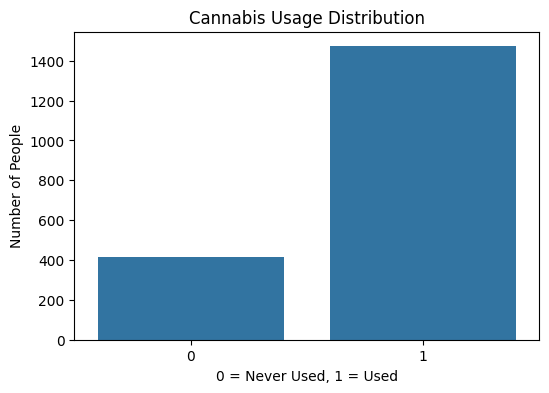

In [9]:
# -----------------------------
# Target variable distribution
# -----------------------------
target = "Cannabis_binary"

print("Class counts:")
print(df[target].value_counts())

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x=df[target])
plt.title("Cannabis Usage Distribution")
plt.xlabel("0 = Never Used, 1 = Used")
plt.ylabel("Number of People")
plt.show()

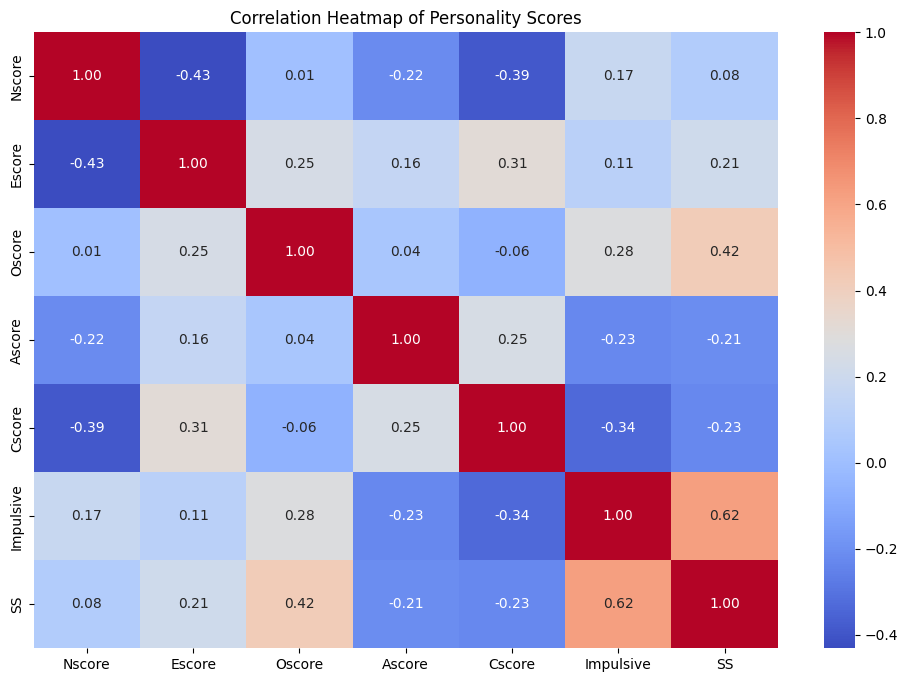

In [10]:
# -----------------------------
# Correlation heatmap
# -----------------------------
plt.figure(figsize=(12,8))

corr_cols = ["Nscore","Escore","Oscore","Ascore","Cscore","Impulsive","SS"]
corr_matrix = df[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Personality Scores")
plt.show()

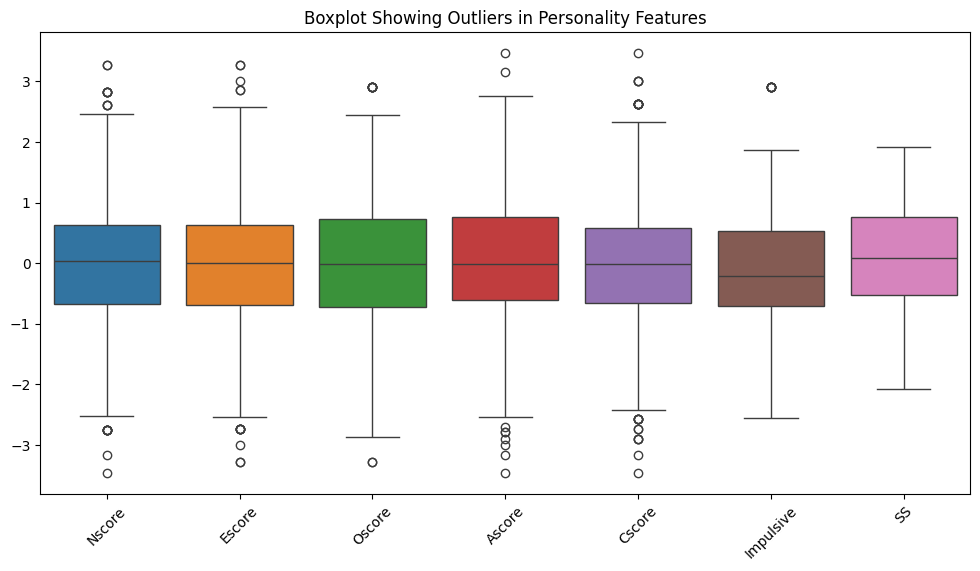

In [11]:
# -----------------------------
# Outlier detection using boxplot
# -----------------------------
plt.figure(figsize=(12,6))
sns.boxplot(data=df[corr_cols])
plt.xticks(rotation=45)
plt.title("Boxplot Showing Outliers in Personality Features")
plt.show()

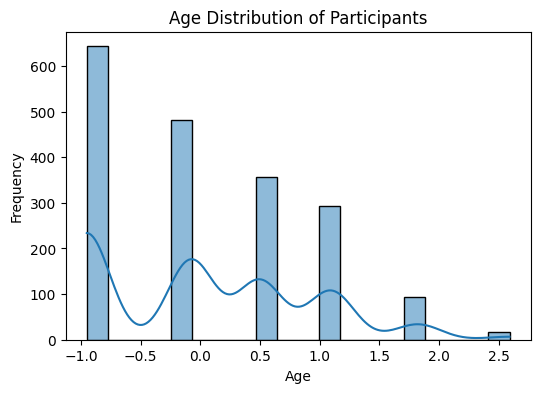

In [12]:
# -----------------------------
# Age distribution
# -----------------------------
plt.figure(figsize=(6,4))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution of Participants")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

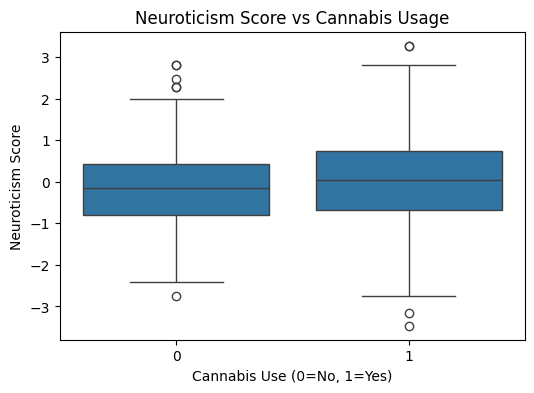

In [13]:
# -----------------------------
# Neuroticism vs Cannabis usage
# -----------------------------
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Cannabis_binary"], y=df["Nscore"])
plt.title("Neuroticism Score vs Cannabis Usage")
plt.xlabel("Cannabis Use (0=No, 1=Yes)")
plt.ylabel("Neuroticism Score")
plt.show()